In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import cv2
import os

In [ ]:
video_path = '/content/drive/MyDrive/SpatialAI/data/raw_video/desk video.mp4'  # change filename if different
output_folder = '/content/drive/MyDrive/SpatialAI/data/raw_images'

os.makedirs(output_folder, exist_ok=True)

In [ ]:
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Original video FPS: {fps}")

frame_interval = int(fps / 1)  # extract 2 frames per second
count = 0
saved = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if count % frame_interval == 0:
        filename = os.path.join(output_folder, f"frame_{saved:04d}.jpg")
        cv2.imwrite(filename, frame)
        saved += 1
    count += 1

cap.release()
print(f"Extracted {saved} frames.")

Original video FPS: 22.711382682245514
Extracted 36 frames.


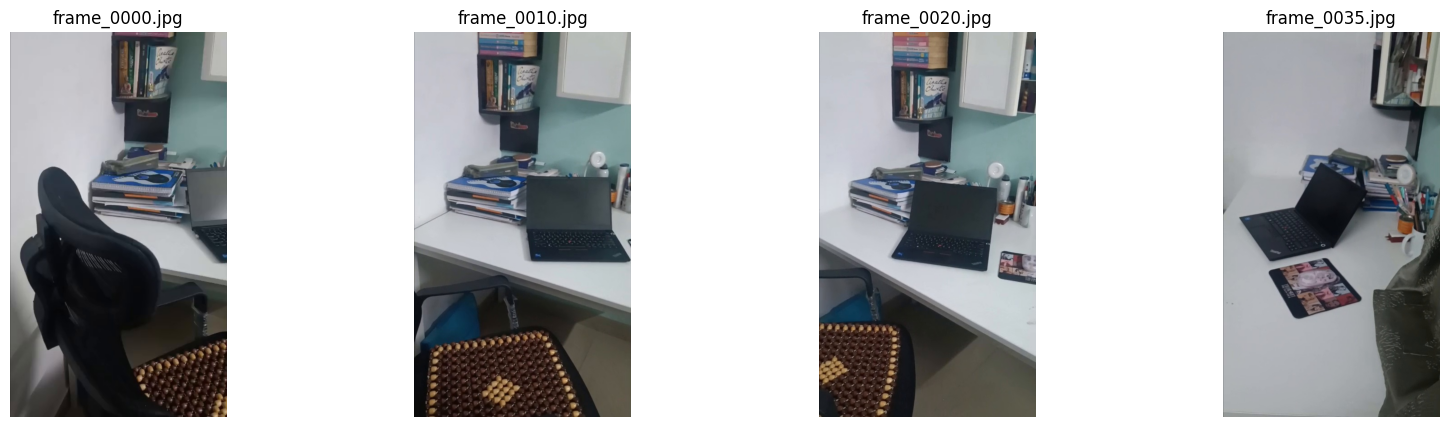

In [7]:
import matplotlib.pyplot as plt

sample_frames = ['frame_0000.jpg', 'frame_0010.jpg', 'frame_0020.jpg', 'frame_0035.jpg']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, fname in zip(axes, sample_frames):
    img = cv2.imread(os.path.join(output_folder, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads as BGR, matplotlib expects RGB
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')
plt.show()